In [ ]:
#1 import libraries
# Basic libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
# Dataset and ML tools
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
# Models
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
# Evaluation
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

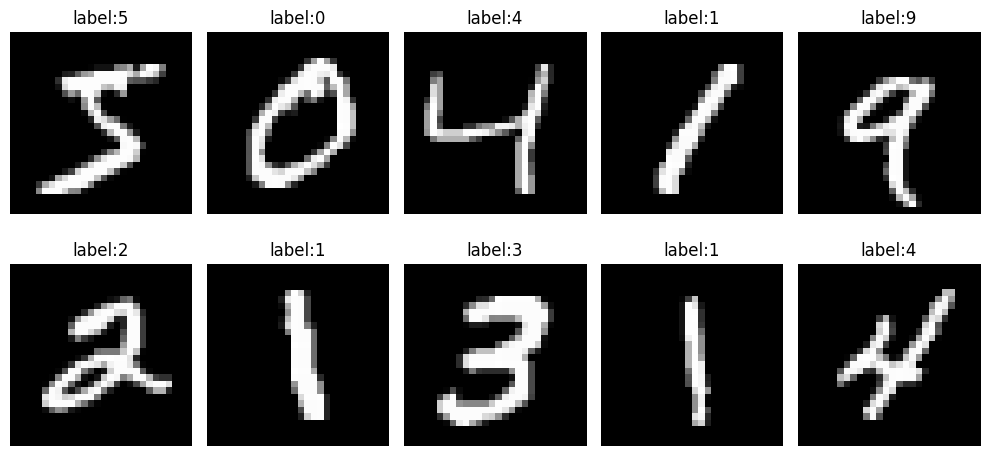

In [ ]:
#2 load dataset
mnist = fetch_openml('mnist_784', version=1, as_frame=True)

X=mnist.data
y=mnist.target

plt.figure(figsize=(10,5))
for i in range(10):
  image=X.iloc[i].values.reshape(28,28)
  label=y.iloc[i]

  plt.subplot(2,5,i+1)
  plt.imshow(image, cmap='gray')
  plt.title(f'label:{label}')
  plt.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
#3 preprocessing (normalization)

X=X/255.0
y=y.astype(int)


In [ ]:
#4 train test split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

In [ ]:
#5 model 1
log_reg=LogisticRegression(max_iter=1000,solver='lbfgs',multi_class='multinomial',n_jobs=-1)
log_reg.fit(X_train,y_train)


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


LogisticRegression(max_iter=1000, multi_class='multinomial', n_jobs=-1)

In [ ]:
y_pred_log = log_reg.predict(X_test)

In [ ]:
log_accuracy = accuracy_score(y_test, y_pred_log)

print("Logistic Regression Accuracy:", log_accuracy)
print("Accuracy percentage:", log_accuracy * 100)
print(classification_report(y_test, y_pred_log))

Logistic Regression Accuracy: 0.9215
Accuracy percentage: 92.15
              precision    recall  f1-score   support

           0       0.95      0.97      0.96      1381
           1       0.95      0.97      0.96      1575
           2       0.93      0.90      0.91      1398
           3       0.90      0.89      0.90      1428
           4       0.93      0.92      0.93      1365
           5       0.88      0.87      0.88      1263
           6       0.94      0.96      0.95      1375
           7       0.93      0.94      0.94      1459
           8       0.89      0.88      0.89      1365
           9       0.90      0.89      0.89      1391

    accuracy                           0.92     14000
   macro avg       0.92      0.92      0.92     14000
weighted avg       0.92      0.92      0.92     14000



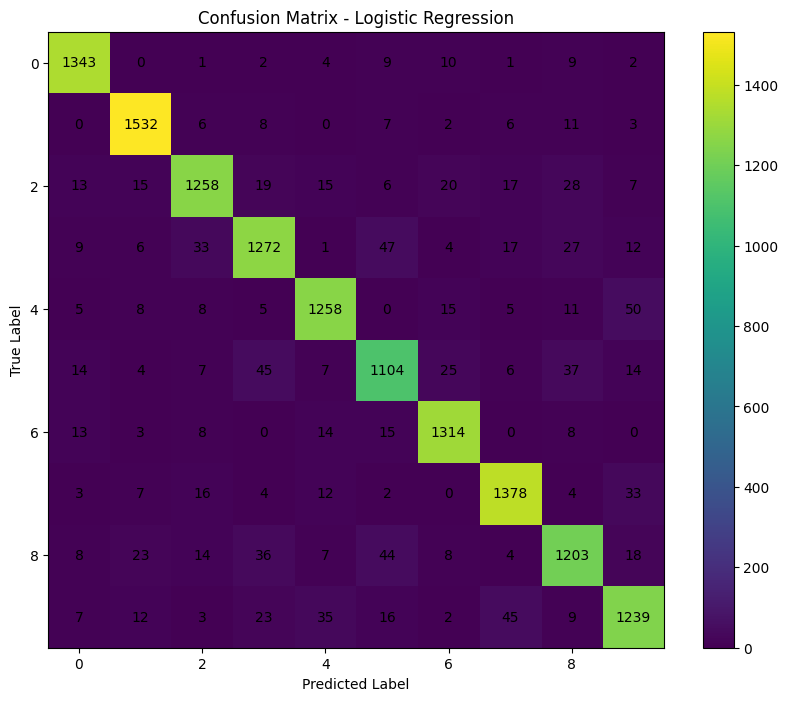

In [ ]:
cm_log = confusion_matrix(y_test, y_pred_log)

plt.figure(figsize=(10, 8))
plt.imshow(cm_log)
plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.colorbar()

for i in range(10):
    for j in range(10):
        plt.text(j, i, cm_log[i, j], ha="center", va="center")

plt.show()

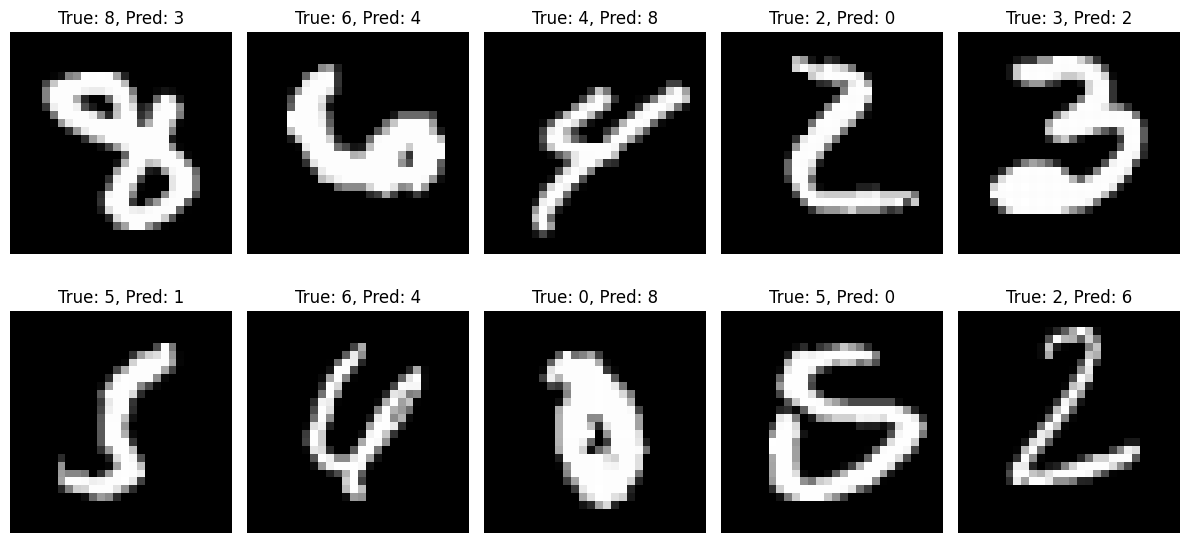

In [ ]:
wrong_indices = np.where(y_pred_log != y_test.to_numpy())[0]

plt.figure(figsize=(12, 6))

for i, wrong_index in enumerate(wrong_indices[:10]):
    image = X_test.iloc[wrong_index].values.reshape(28, 28)
    true_label = y_test.iloc[wrong_index]
    predicted_label = y_pred_log[wrong_index]

    plt.subplot(2, 5, i + 1)
    plt.imshow(image, cmap='gray')
    plt.title(f"True: {true_label}, Pred: {predicted_label}")
    plt.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
# 6 model 2
X_train_knn = X_train[:10000]
y_train_knn = y_train[:10000]

X_test_knn = X_test[:2000]
y_test_knn = y_test[:2000]

In [ ]:
knn = KNeighborsClassifier(n_neighbors=3)

knn.fit(X_train_knn, y_train_knn)

KNeighborsClassifier(n_neighbors=3)

In [ ]:
knn_accuracy = accuracy_score(y_test_knn, y_pred_knn)

print("KNN Accuracy:", knn_accuracy)
print("Accuracy percentage:", knn_accuracy * 100)
print(classification_report(y_test_knn, y_pred_knn))

KNN Accuracy: 0.949
Accuracy percentage: 94.89999999999999
              precision    recall  f1-score   support

           0       0.95      1.00      0.97       216
           1       0.89      0.99      0.94       221
           2       0.97      0.92      0.94       185
           3       0.96      0.97      0.96       207
           4       0.98      0.94      0.96       195
           5       0.96      0.94      0.95       190
           6       0.96      0.98      0.97       207
           7       0.95      0.93      0.94       214
           8       0.99      0.89      0.94       174
           9       0.91      0.93      0.92       191

    accuracy                           0.95      2000
   macro avg       0.95      0.95      0.95      2000
weighted avg       0.95      0.95      0.95      2000



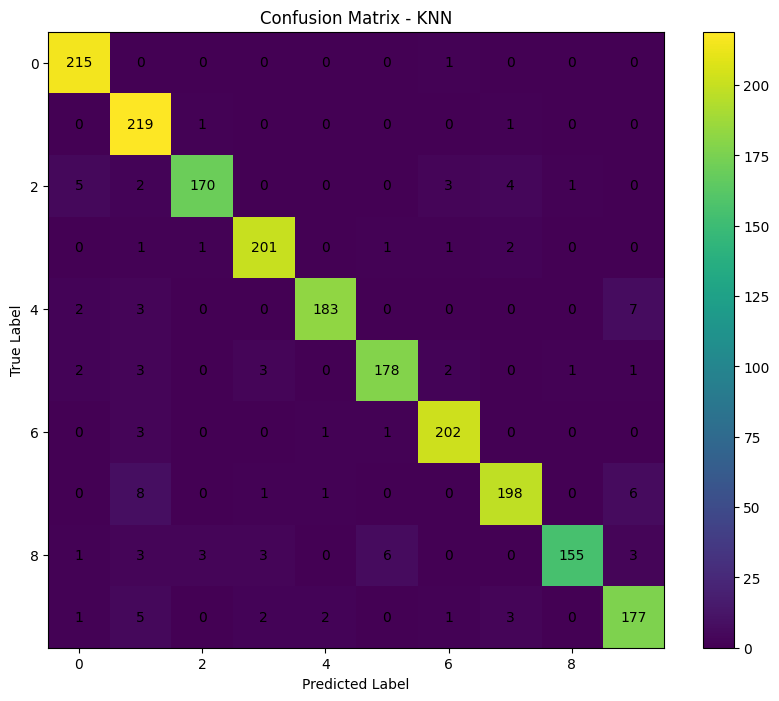

In [ ]:
cm_knn = confusion_matrix(y_test_knn, y_pred_knn)

plt.figure(figsize=(10, 8))
plt.imshow(cm_knn)
plt.title("Confusion Matrix - KNN")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.colorbar()

for i in range(10):
    for j in range(10):
        plt.text(j, i, cm_knn[i, j], ha="center", va="center")

plt.show()


In [ ]:
#Test different values of K
k_accuracies = []

for k in k_values:
    knn_model = KNeighborsClassifier(n_neighbors=k)
    knn_model.fit(X_train_knn, y_train_knn)

    y_pred = knn_model.predict(X_test_knn)
    acc = accuracy_score(y_test_knn, y_pred)

    k_accuracies.append(acc)
    print(f"K = {k}, Accuracy = {acc}")

K = 1, Accuracy = 0.956
K = 3, Accuracy = 0.949
K = 5, Accuracy = 0.948
K = 7, Accuracy = 0.9405


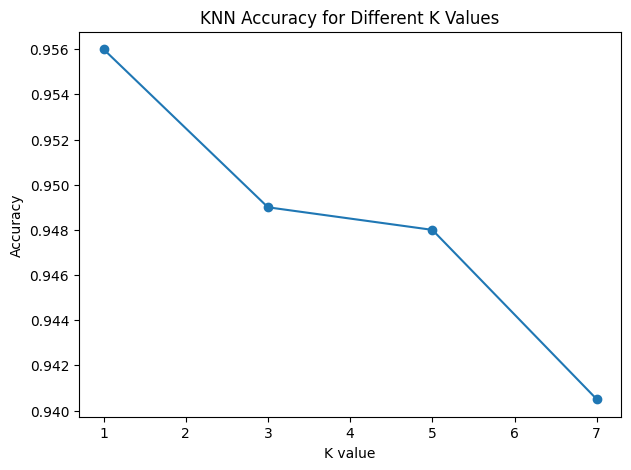

In [ ]:
plt.figure(figsize=(7, 5))
plt.plot(k_values, k_accuracies, marker='o')
plt.xlabel("K value")
plt.ylabel("Accuracy")
plt.title("KNN Accuracy for Different K Values")
plt.show()

In [ ]:
# 7 model 3
dt=DecisionTreeClassifier(random_state=42,max_depth=20)
dt.fit(X_train,y_train)

DecisionTreeClassifier(max_depth=20, random_state=42)

In [ ]:
y_pred_dt=dt.predict(X_test)

In [ ]:
dt_accuracy = accuracy_score(y_test, y_pred_dt)

print("Decision Tree Accuracy:", dt_accuracy)
print("Decision Tree Accuracy Percentage:", dt_accuracy * 100)
print(classification_report(y_test, y_pred_dt))

Decision Tree Accuracy: 0.8768571428571429
Decision Tree Accuracy Percentage: 87.68571428571428
              precision    recall  f1-score   support

           0       0.91      0.94      0.92      1381
           1       0.95      0.96      0.95      1575
           2       0.87      0.85      0.86      1398
           3       0.85      0.85      0.85      1428
           4       0.86      0.88      0.87      1365
           5       0.82      0.83      0.82      1263
           6       0.92      0.89      0.90      1375
           7       0.90      0.92      0.91      1459
           8       0.84      0.80      0.82      1365
           9       0.83      0.84      0.84      1391

    accuracy                           0.88     14000
   macro avg       0.88      0.88      0.88     14000
weighted avg       0.88      0.88      0.88     14000



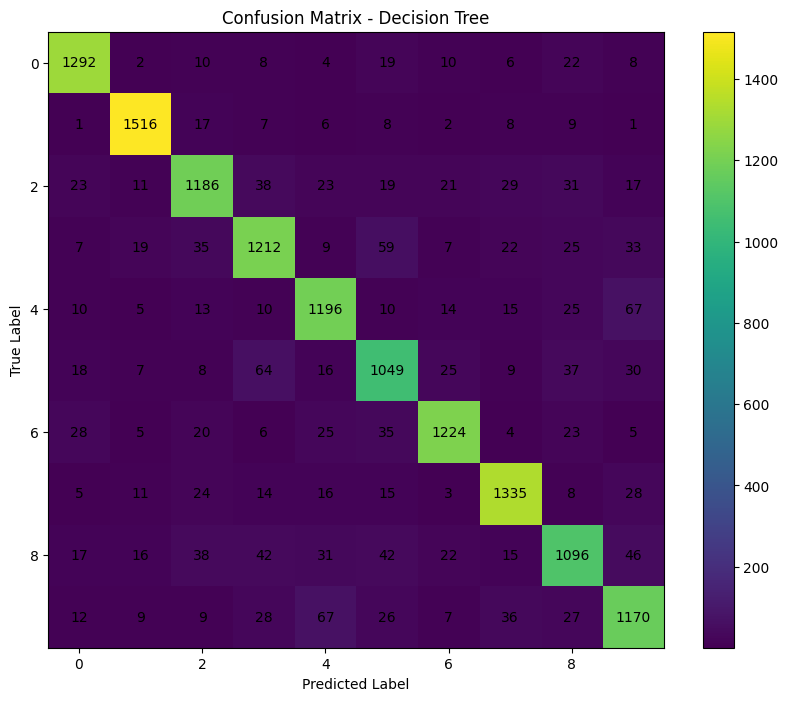

In [ ]:
cm_dt=confusion_matrix(y_test,y_pred_dt)

plt.figure(figsize=(10, 8))
plt.imshow(cm_dt)
plt.title("Confusion Matrix - Decision Tree")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.colorbar()

for i in range(10):
    for j in range(10):
        plt.text(j, i, cm_dt[i, j], ha="center", va="center")

plt.show()

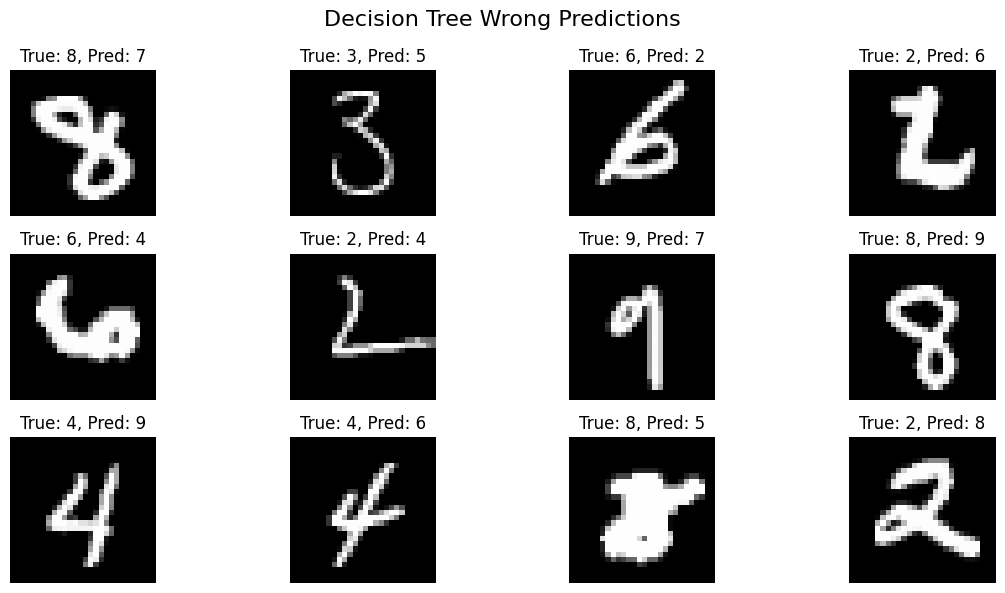

In [ ]:
# Find wrong predictions
wrong_indices_dt = np.where(y_test.to_numpy() != y_pred_dt)[0]

plt.figure(figsize=(12, 6))

for i, idx in enumerate(wrong_indices_dt[:12]):
    image = X_test.iloc[idx].to_numpy().reshape(28, 28)
    true_label = y_test.iloc[idx]
    predicted_label = y_pred_dt[idx]

    plt.subplot(3, 4, i + 1)
    plt.imshow(image, cmap="gray")
    plt.title(f"True: {true_label}, Pred: {predicted_label}")
    plt.axis("off")

plt.suptitle("Decision Tree Wrong Predictions", fontsize=16)
plt.tight_layout()
plt.show()

In [ ]:
# 8 Model Comparison
model_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "KNN",
        "Decision Tree"
    ],
    "Accuracy": [
        0.9215,
        0.9490,
        0.8768
    ],
    "Accuracy Percentage": [
        0.9215 * 100,
        0.9490 * 100,
        0.8768 * 100
    ],
    "Evaluation Data": [
        "Full test set (14000 samples)",
        "Subset test set (2000 samples)",
        "Full test set (14000 samples)"
    ]
})

model_comparison

,Model,Accuracy,Accuracy Percentage,Evaluation Data
0,Logistic Regression,0.9215,92.15,Full test set (14000 samples)
1,KNN,0.9490,94.90,Subset test set (2000 samples)
2,Decision Tree,0.8768,87.68,Full test set (14000 samples)


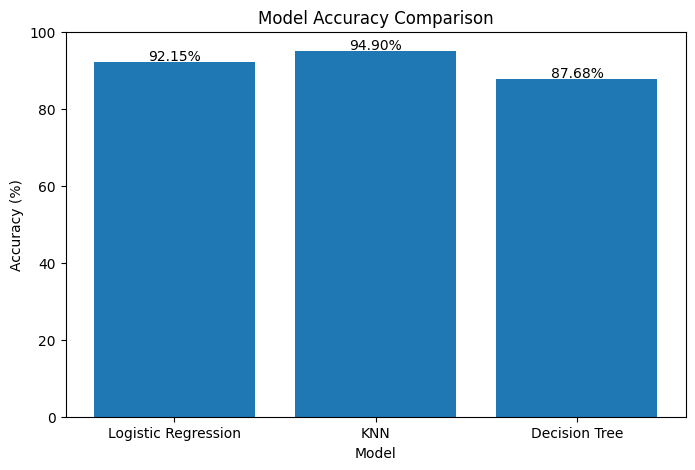

In [ ]:
# 9 Bar chart represtation
plt.figure(figsize=(8, 5))

plt.bar(model_comparison["Model"], model_comparison["Accuracy Percentage"])

plt.xlabel("Model")
plt.ylabel("Accuracy (%)")
plt.title("Model Accuracy Comparison")
plt.ylim(0, 100)

for i, value in enumerate(model_comparison["Accuracy Percentage"]):
    plt.text(i, value + 0.5, f"{value:.2f}%", ha="center")

plt.show()

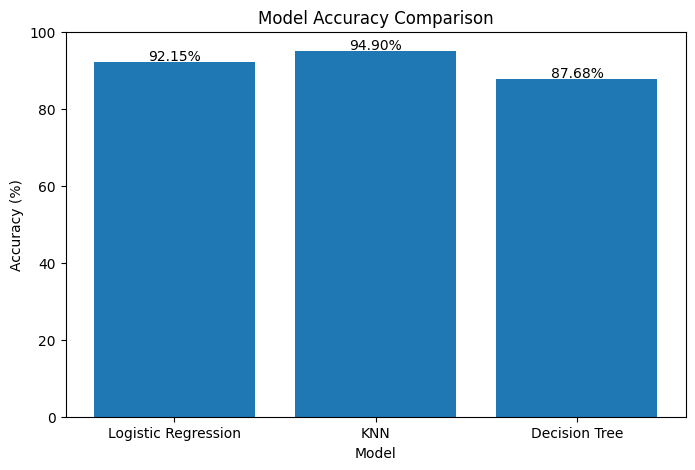

In [ ]:
#for readme
import os

os.makedirs("assets", exist_ok=True)

plt.figure(figsize=(8, 5))
plt.bar(model_comparison["Model"], model_comparison["Accuracy Percentage"])
plt.xlabel("Model")
plt.ylabel("Accuracy (%)")
plt.title("Model Accuracy Comparison")
plt.ylim(0, 100)

for i, value in enumerate(model_comparison["Accuracy Percentage"]):
    plt.text(i, value + 0.5, f"{value:.2f}%", ha="center")

plt.savefig("assets/model_accuracy_comparison.png", bbox_inches="tight", dpi=300)
plt.show()

In [106]:
%%writefile requirements.txt
gradio
scikit-learn
numpy
pillow
joblib
opencv-python-headless

Overwriting requirements.txt


In [112]:
%%writefile main.py
import joblib
import numpy as np

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score


MODEL_PATH = "knn_mnist.joblib"

# we can increase it later to 60000 for better accuracy but slower prediction.
TRAIN_LIMIT = 30000
TEST_LIMIT = 8000


def main():
    print("Downloading MNIST dataset...")

    mnist = fetch_openml("mnist_784", version=1, as_frame=False)

    X = mnist.data.astype(np.float32) / 255.0
    y = mnist.target.astype(int)

    print("Dataset loaded:", X.shape, y.shape)

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        train_size=TRAIN_LIMIT,
        test_size=TEST_LIMIT,
        random_state=42,
        stratify=y
    )

    print("Training KNN model...")

    knn = KNeighborsClassifier(
        n_neighbors=3,
        weights="distance",
        metric="euclidean",
        n_jobs=-1
    )

    knn.fit(X_train, y_train)

    print("Testing model...")
    y_pred = knn.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)

    print(f"Accuracy: {accuracy:.4f}")

    model_package = {
        "model": knn,
        "accuracy": accuracy,
        "train_limit": TRAIN_LIMIT,
        "pixel_scale": "0_to_1",
        "input_shape": "28x28 flattened"
    }

    joblib.dump(model_package, MODEL_PATH)

    print(f"Model saved as {MODEL_PATH}")


if __name__ == "__main__":
    main()

Overwriting main.py


In [116]:
import joblib
import numpy as np
import gradio as gr
import cv2

from PIL import Image


MODEL_PATH = "knn_mnist.joblib"


# ----------------------------
# Load trained KNN model
# ----------------------------
model_package = joblib.load(MODEL_PATH)
knn = model_package["model"]
MODEL_ACCURACY = model_package.get("accuracy", None)
TRAIN_LIMIT = model_package.get("train_limit", "MNIST")


# ----------------------------
# Editable design section
# Change colors/fonts here
# ----------------------------
APP_CSS = """
:root {
    --bg-almond: #EFE1D5;
    --bg-almond-light: #F8F1EA;
    --coffee: #2E0D14;
    --coffee-2: #3A121A;
    --coffee-3: #1C070C;
    --rose-coffee: #4A202A;
    --muted-coffee: #A58E80;
    --cream: #EFE1D5;
    --cream-2: #FFF8F1;
    --ink: #2E0D14;
    --shadow: rgba(46, 13, 20, 0.28);
}

.gradio-container {
    background:
        radial-gradient(circle at top, rgba(255, 255, 255, 0.55), transparent 34%),
        var(--bg-almond) !important;
    color: var(--coffee-2) !important;
    font-family: Inter, ui-sans-serif, system-ui, sans-serif !important;
}

#hero {
    text-align: center;
    padding: 30px 16px 18px 16px;
    color: var(--coffee) !important;
}

#hero h1 {
    color: var(--coffee) !important;
    font-family: Georgia, 'Times New Roman', serif !important;
    font-size: 42px;
    font-weight: 500;
    letter-spacing: 1px;
    margin-bottom: 8px;
}

#hero p {
    color: var(--rose-coffee) !important;
    font-size: 15px;
    letter-spacing: 0.3px;
}

#hero strong {
    color: var(--coffee) !important;
    font-weight: 800 !important;
}

#main-card {
    background: linear-gradient(180deg, var(--coffee-2), var(--coffee));
    border: 2px solid var(--rose-coffee);
    border-radius: 26px;
    padding: 26px;
    box-shadow: 0 28px 80px var(--shadow);
    max-width: 1180px;
    margin: 0 auto;
}

#tip-pill {
    background: var(--coffee-3);
    border: 1px solid rgba(239, 225, 213, 0.12);
    color: var(--cream) !important;
    border-radius: 10px;
    padding: 10px 14px;
    margin-bottom: 18px;
}

.section-title h3 {
    color: var(--cream) !important;
    font-size: 13px !important;
    letter-spacing: 1.6px;
    text-transform: uppercase;
    margin-bottom: 10px;
}

#draw-box {
    background: var(--cream) !important;
    border: 2px solid var(--rose-coffee);
    border-radius: 18px;
    overflow: hidden;
}

#predict-panel {
    min-height: 270px;
}

.prediction-card {
    background: linear-gradient(180deg, #4A202A, #351019);
    border: 1px solid rgba(239, 225, 213, 0.16);
    border-radius: 20px;
    min-height: 260px;
    display: flex;
    flex-direction: column;
    align-items: center;
    justify-content: center;
    text-align: center;
    box-shadow: inset 0 0 30px rgba(0, 0, 0, 0.18);
}

.prediction-label {
    color: var(--muted-coffee);
    text-transform: uppercase;
    letter-spacing: 2px;
    font-size: 12px;
    margin-bottom: 8px;
}

.prediction-digit {
    color: var(--cream-2);
    font-family: Georgia, 'Times New Roman', serif;
    font-size: 154px;
    line-height: 0.95;
    font-weight: 700;
    text-shadow: 0 12px 38px rgba(0, 0, 0, 0.34);
}

.prediction-confidence {
    color: var(--cream);
    font-size: 16px;
    margin-top: 10px;
}

.prediction-subtext {
    color: var(--muted-coffee);
    font-size: 12px;
    margin-top: 8px;
}

#predict-btn {
    background: linear-gradient(90deg, var(--cream-2), var(--cream)) !important;
    color: var(--coffee) !important;
    font-weight: 900 !important;
    letter-spacing: 1px;
    border-radius: 12px !important;
    border: none !important;
    min-height: 48px;
}

#clear-btn {
    background: transparent !important;
    color: var(--cream) !important;
    border: 1px solid var(--cream) !important;
    border-radius: 12px !important;
    min-height: 48px;
}

#summary-card {
    background: linear-gradient(180deg, var(--coffee-2), var(--coffee));
    border: 2px solid var(--rose-coffee);
    border-radius: 24px;
    padding: 24px;
    box-shadow: 0 22px 70px var(--shadow);
    max-width: 1180px;
    margin: 22px auto 0 auto;
}

.summary-shell {
    color: var(--cream);
}

.summary-header {
    display: flex;
    justify-content: space-between;
    gap: 20px;
    align-items: flex-end;
    margin-bottom: 18px;
}

.summary-title {
    font-family: Georgia, 'Times New Roman', serif;
    font-size: 27px;
    color: var(--cream-2);
    margin: 0;
}

.summary-subtitle {
    color: var(--muted-coffee);
    font-size: 13px;
    margin-top: 5px;
}

.summary-badge {
    background: var(--coffee-3);
    border: 1px solid rgba(239, 225, 213, 0.13);
    border-radius: 999px;
    padding: 8px 12px;
    color: var(--cream);
    font-size: 12px;
    white-space: nowrap;
}

.summary-grid {
    display: grid;
    grid-template-columns: 1fr 1.2fr;
    gap: 20px;
}

.summary-insight {
    background: var(--coffee-3);
    border: 1px solid rgba(239, 225, 213, 0.12);
    border-radius: 18px;
    padding: 18px;
}

.insight-big {
    color: var(--cream-2);
    font-size: 20px;
    font-weight: 800;
    margin-bottom: 8px;
}

.insight-line {
    color: var(--muted-coffee);
    font-size: 13px;
    line-height: 1.55;
}

.confidence-table {
    background: var(--coffee-3);
    border: 1px solid rgba(239, 225, 213, 0.12);
    border-radius: 18px;
    padding: 16px;
}

.conf-row {
    display: grid;
    grid-template-columns: 34px 1fr 58px;
    gap: 12px;
    align-items: center;
    margin: 11px 0;
}

.conf-digit {
    color: var(--cream-2);
    font-weight: 900;
    font-size: 15px;
}

.conf-track {
    background: var(--coffee);
    border-radius: 999px;
    height: 16px;
    overflow: hidden;
    border: 1px solid rgba(239, 225, 213, 0.08);
}

.conf-fill {
    height: 100%;
    background: linear-gradient(90deg, var(--cream-2), var(--cream));
    border-radius: 999px;
}

.conf-percent {
    color: var(--cream);
    text-align: right;
    font-weight: 700;
    font-size: 13px;
}

.conf-row.not-top .conf-digit,
.conf-row.not-top .conf-percent {
    color: var(--muted-coffee);
}

.conf-row.not-top .conf-fill {
    opacity: 0.42;
}

#footer-note {
    color: var(--rose-coffee) !important;
    text-align: center;
    font-size: 13px;
    margin-top: 18px;
}

@media (max-width: 900px) {
    #hero h1 {
        font-size: 32px;
    }

    .prediction-digit {
        font-size: 120px;
    }

    .summary-header,
    .summary-grid {
        display: block;
    }

    .summary-badge {
        display: inline-block;
        margin-top: 12px;
    }

    .confidence-table {
        margin-top: 16px;
    }
}
"""


EMPTY_PREDICTION_HTML = """
<div class="prediction-card">
    <div class="prediction-label">Predicted Digit</div>
    <div class="prediction-digit">?</div>
    <div class="prediction-confidence">Draw first</div>
    <div class="prediction-subtext">The result will appear here.</div>
</div>
"""


EMPTY_SUMMARY_HTML = """
<div class="summary-shell">
    <div class="summary-header">
        <div>
            <h2 class="summary-title">Confidence Summary</h2>
            <div class="summary-subtitle">After prediction, this section will show all digit probabilities from 0 to 9.</div>
        </div>
        <div class="summary-badge">Waiting for drawing</div>
    </div>
    <div class="summary-insight">
        <div class="insight-big">No digit predicted yet.</div>
        <div class="insight-line">Draw one clear digit, press Predict Digit, then check both the 28x28 preview and the probability bars.</div>
    </div>
</div>
"""


# ----------------------------
# White canvas for drawing
# ----------------------------
def blank_canvas():
    canvas = np.ones((280, 280, 3), dtype=np.uint8) * 255

    return {
        "background": canvas,
        "layers": [],
        "composite": canvas
    }


# ----------------------------
# Extract actual canvas image from Gradio
# ----------------------------
def extract_canvas(editor_value):
    if editor_value is None:
        return None

    if isinstance(editor_value, dict):
        image_array = editor_value.get("composite")
    else:
        image_array = editor_value

    if image_array is None:
        return None

    image_array = image_array.astype("uint8")

    # Remove alpha channel if present
    if image_array.shape[-1] == 4:
        image_array = image_array[:, :, :3]

    return image_array


# ----------------------------
# Center digit using center of mass
# ----------------------------
def center_digit(image_28):
    """
    image_28 is a 28x28 grayscale image.
    Digit should be white on black.
    This function shifts the digit so its center of mass is near the center.
    """

    moments = cv2.moments(image_28)

    if moments["m00"] == 0:
        return image_28

    cx = moments["m10"] / moments["m00"]
    cy = moments["m01"] / moments["m00"]

    shift_x = 14 - cx
    shift_y = 14 - cy

    transform_matrix = np.float32([
        [1, 0, shift_x],
        [0, 1, shift_y]
    ])

    centered = cv2.warpAffine(
        image_28,
        transform_matrix,
        (28, 28),
        borderValue=0
    )

    return centered


# ----------------------------
# Convert drawing into proper MNIST format
# ----------------------------
def preprocess_digit(editor_value):
    """
    Final output:
    - white digit on black background
    - centered
    - square-safe
    - 28x28
    - flattened to 784 pixels
    """

    canvas = extract_canvas(editor_value)

    if canvas is None:
        return None, None

    # Convert RGB canvas to grayscale
    gray = cv2.cvtColor(canvas, cv2.COLOR_RGB2GRAY)

    # User draws black on white.
    # MNIST is white digit on black.
    inverted = 255 - gray

    # Smooth slightly so mouse strokes look less jagged
    blurred = cv2.GaussianBlur(inverted, (5, 5), 0)

    # Convert to clean binary ink mask
    _, binary = cv2.threshold(
        blurred,
        0,
        255,
        cv2.THRESH_BINARY + cv2.THRESH_OTSU
    )

    # Remove tiny noise
    kernel = np.ones((3, 3), np.uint8)
    binary = cv2.morphologyEx(binary, cv2.MORPH_OPEN, kernel, iterations=1)

    # Make strokes slightly fuller
    binary = cv2.dilate(binary, kernel, iterations=1)

    # Find connected ink shapes
    contours, _ = cv2.findContours(
        binary,
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_SIMPLE
    )

    if len(contours) == 0:
        return None, None

    # Use the largest drawn component as the digit
    largest_contour = max(contours, key=cv2.contourArea)

    if cv2.contourArea(largest_contour) < 20:
        return None, None

    x, y, w, h = cv2.boundingRect(largest_contour)

    # Crop the digit from the original inverted grayscale image
    digit_crop = inverted[y:y + h, x:x + w]

    # Also crop the binary mask and remove background noise
    mask_crop = binary[y:y + h, x:x + w]
    digit_crop = cv2.bitwise_and(digit_crop, digit_crop, mask=mask_crop)

    # Resize while keeping aspect ratio
    crop_h, crop_w = digit_crop.shape

    scale = 20.0 / max(crop_w, crop_h)
    new_w = max(1, int(crop_w * scale))
    new_h = max(1, int(crop_h * scale))

    resized = cv2.resize(
        digit_crop,
        (new_w, new_h),
        interpolation=cv2.INTER_AREA
    )

    # Place resized digit into 28x28 black canvas
    mnist_image = np.zeros((28, 28), dtype=np.uint8)

    x_offset = (28 - new_w) // 2
    y_offset = (28 - new_h) // 2

    mnist_image[
        y_offset:y_offset + new_h,
        x_offset:x_offset + new_w
    ] = resized

    # Shift by center of mass
    mnist_image = center_digit(mnist_image)

    # Normalize to match training data
    model_input = mnist_image.astype(np.float32) / 255.0
    model_input = model_input.reshape(1, 784)

    preview = Image.fromarray(mnist_image)

    return model_input, preview


# ----------------------------
# HTML helpers for prettier output
# ----------------------------
def make_prediction_card(prediction, top_probability):
    percentage = top_probability * 100

    return f"""
    <div class="prediction-card">
        <div class="prediction-label">Predicted Digit</div>
        <div class="prediction-digit">{prediction}</div>
        <div class="prediction-confidence">{percentage:.1f}% confidence</div>
        <div class="prediction-subtext">KNN decision from nearest MNIST examples</div>
    </div>
    """


def make_confidence_summary(prediction, confidence_dict):
    sorted_digits = sorted(confidence_dict.items(), key=lambda item: item[1], reverse=True)
    top_digit, top_prob = sorted_digits[0]
    second_digit, second_prob = sorted_digits[1]
    third_digit, third_prob = sorted_digits[2]

    gap = top_prob - second_prob
    model_accuracy_text = "Not stored"
    if MODEL_ACCURACY is not None:
        model_accuracy_text = f"{MODEL_ACCURACY * 100:.2f}% test accuracy"

    rows_html = ""

    for digit in range(10):
        digit_text = str(digit)
        prob = confidence_dict.get(digit_text, 0.0)
        percent = prob * 100
        row_class = "conf-row" if digit_text == str(prediction) else "conf-row not-top"

        rows_html += f"""
        <div class="{row_class}">
            <div class="conf-digit">{digit_text}</div>
            <div class="conf-track">
                <div class="conf-fill" style="width: {percent:.2f}%"></div>
            </div>
            <div class="conf-percent">{percent:.1f}%</div>
        </div>
        """

    return f"""
    <div class="summary-shell">
        <div class="summary-header">
            <div>
                <h2 class="summary-title">Confidence Summary</h2>
                <div class="summary-subtitle">Detailed probability breakdown across all 10 digit classes.</div>
            </div>
            <div class="summary-badge">{model_accuracy_text} · trained on {TRAIN_LIMIT} samples</div>
        </div>

        <div class="summary-grid">
            <div class="summary-insight">
                <div class="insight-big">Top prediction: {top_digit} at {top_prob * 100:.1f}%</div>
                <div class="insight-line">
                    Runner-up: {second_digit} at {second_prob * 100:.1f}%<br>
                    Third candidate: {third_digit} at {third_prob * 100:.1f}%<br><br>
                    Confidence gap between first and second: {gap * 100:.1f} percentage points.
                    A bigger gap usually means the KNN model found a clearer nearest-neighbor match.
                </div>
            </div>

            <div class="confidence-table">
                {rows_html}
            </div>
        </div>
    </div>
    """


# ----------------------------
# Prediction function
# ----------------------------
def predict_digit(editor_value):
    model_input, _ = preprocess_digit(editor_value)

    if model_input is None:
        return EMPTY_PREDICTION_HTML, EMPTY_SUMMARY_HTML

    prediction = int(knn.predict(model_input)[0])

    probabilities = knn.predict_proba(model_input)[0]
    class_labels = knn.classes_

    confidence_dict = {
        str(label): float(prob)
        for label, prob in zip(class_labels, probabilities)
    }

    top_probability = confidence_dict.get(str(prediction), 0.0)

    prediction_html = make_prediction_card(prediction, top_probability)
    summary_html = make_confidence_summary(prediction, confidence_dict)

    return prediction_html, summary_html

# ----------------------------
# Clear function
# ----------------------------
def clear_canvas():
    return blank_canvas(), EMPTY_PREDICTION_HTML, EMPTY_SUMMARY_HTML,


# ----------------------------
# Gradio UI
# ----------------------------
with gr.Blocks(css=APP_CSS, theme=gr.themes.Soft()) as demo:
    gr.Markdown(
        """
        # MNIST KNN Digit Recognizer
        Draw a digit from **0 to 9** to compare against stored MNIST examples.
        """,
        elem_id="hero"
    )

    with gr.Group(elem_id="main-card"):
        gr.Markdown(
            "💡 Tip: draw one large, centered digit. The app converts it into a clean 28x28 MNIST-style square before prediction.",
            elem_id="tip-pill"
        )

        with gr.Row(equal_height=True):
            with gr.Column(scale=5):
                gr.Markdown("### 1. Drawing Canvas", elem_classes="section-title")

                sketchpad = gr.ImageEditor(
                    value=blank_canvas,
                    type="numpy",
                    image_mode="RGB",
                    sources=(),
                    canvas_size=(280, 280),
                    fixed_canvas=True,
                    brush=gr.Brush(
                        default_size=18,
                        colors=["#000000"],
                        default_color="#000000",
                        color_mode="fixed"
                    ),
                    eraser=gr.Eraser(default_size=24),
                    layers=False,
                    transforms=[],
                    label="Draw here",
                    elem_id="draw-box"
                )

                with gr.Row():
                    predict_button = gr.Button("PREDICT DIGIT", elem_id="predict-btn")
                    clear_button = gr.Button("CLEAR", elem_id="clear-btn")

            with gr.Column(scale=4, elem_id="predict-panel"):
                gr.Markdown("### 2. Prediction", elem_classes="section-title")

                prediction_output = gr.HTML(
                    value=EMPTY_PREDICTION_HTML
                )

    with gr.Group(elem_id="summary-card"):
        confidence_summary = gr.HTML(
            value=EMPTY_SUMMARY_HTML
        )

    gr.Markdown(
        "Check the 28x28 preview first. If that tiny square looks clean, your KNN prediction has a much better chance of behaving.",
        elem_id="footer-note"
    )

    predict_button.click(
        fn=predict_digit,
        inputs=sketchpad,
        outputs=[prediction_output, confidence_summary]

    )

    clear_button.click(
        fn=clear_canvas,
        inputs=None,
        outputs=[sketchpad, prediction_output, confidence_summary]

    )

if __name__ == "__main__":
    demo.launch(share=True)


/tmp/ipykernel_6441/423041821.py:641: UserWarning: The parameters have been moved from the Blocks constructor to the launch() method in Gradio 6.0: theme, css. Please pass these parameters to launch() instead.
  with gr.Blocks(css=APP_CSS, theme=gr.themes.Soft()) as demo:


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://38d4d548f92d487534.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
